
In this notebook, we use NumPy and Matplotlib to implement Gaussian processes 
from scratch by drawing and visualizing samples from the GP prior and posterior.
 We also created a class in GP.py file to organize the main functionality and 
 applied it across this notebook.

In [ ]:
# Libraries
import matplotlib.pyplot as plt
import numpy as np 
from deep_gp.gp import GaussianProcess
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))

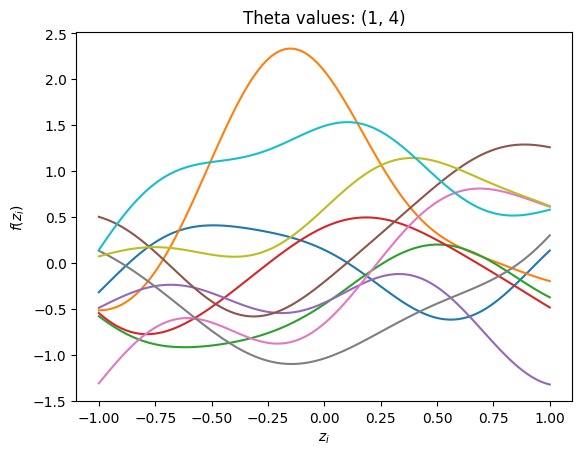

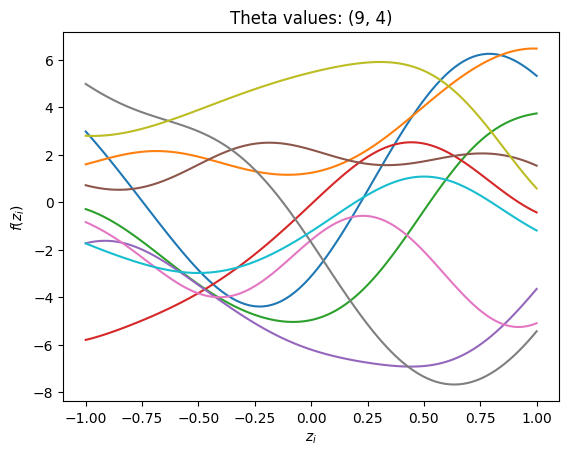

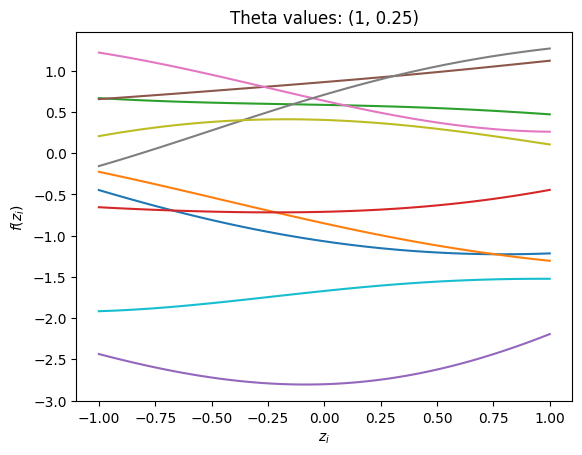

In [4]:
gp = GaussianProcess()

# Sampling from GP with different thetas
thetas = [(1, 4), (9, 4), (1, 0.25)]
num_samples = 10

for theta_0, theta_1 in thetas:
    ker = gp.kernel_matrix_vectorized(gp.z, theta_0, theta_1)
    samples = gp.sample_gp(ker, num_samples)
    for i in range(num_samples):
        plt.plot(gp.z, samples[i])
    plt.title(f'Theta values: ({theta_0}, {theta_1})')
    plt.xlabel(r"$z_i$")
    plt.ylabel(r"$f(z_i)$")
    plt.show()


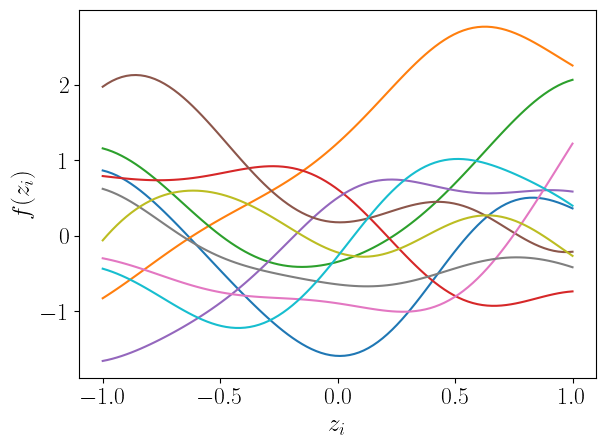

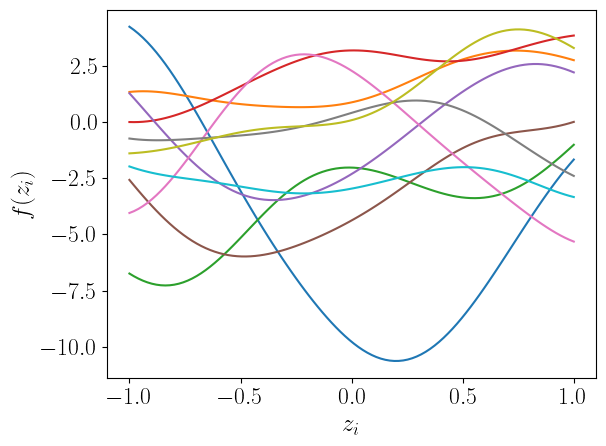

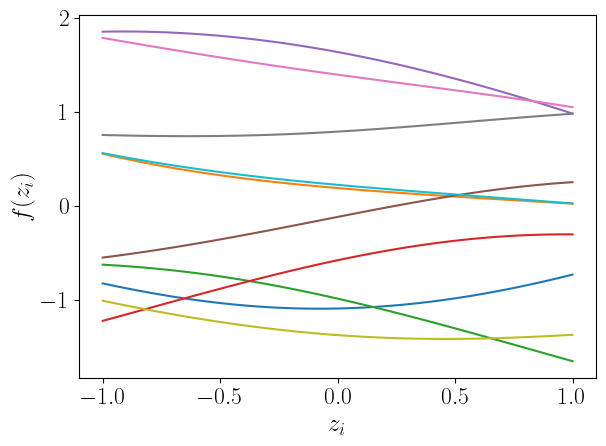

In [5]:
# Apply LaTeX-style font settings 
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "mathtext.fontset": "stix",
    "font.size": 18,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 17,
    "ytick.labelsize": 17,
    "legend.fontsize": 17,
    "figure.titlesize": 18,
})

gp = GaussianProcess()

thetas = [(1, 4), (9, 4), (1, 0.25)]
num_samples = 10

for theta_0, theta_1 in thetas:
    ker = gp.kernel_matrix_vectorized(gp.z, theta_0, theta_1)
    samples = gp.sample_gp(ker, num_samples)
    for i in range(num_samples):
        plt.plot(gp.z, samples[i])
    #plt.title(f'Theta values: ({theta_0}, {theta_1})')
    plt.xlabel(r'$z_i$')
    plt.ylabel(r'$f(z_i)$')
    plt.tight_layout()
    plt.show()


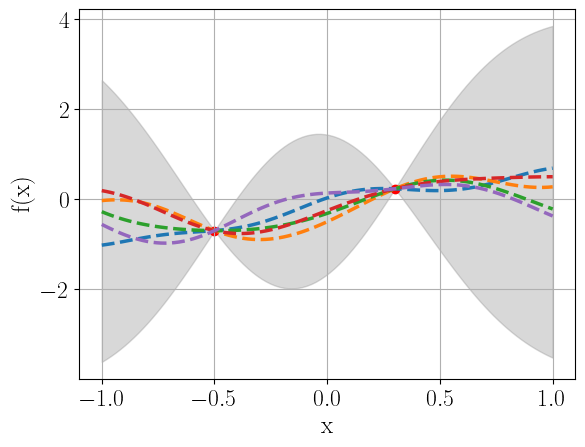

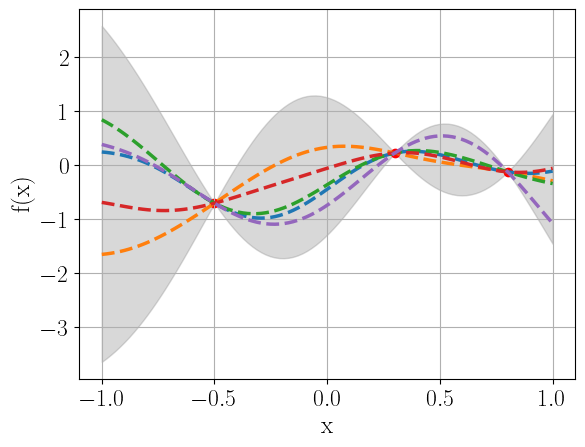

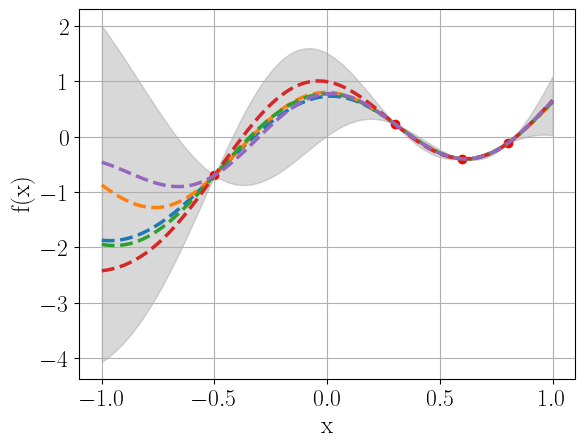

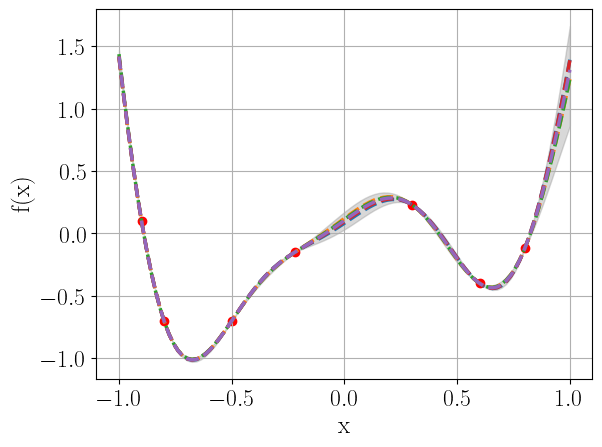

In [6]:
# Part 2: Posterior with increasing training points
datasets = [
    (np.array([0.3, -0.5]), np.array([0.23, -0.7])),
    (np.array([0.3, -0.5, 0.8]), np.array([0.23, -0.7, -0.12])),
    (np.array([0.3, -0.5, 0.8, 0.6]), np.array([0.23, -0.7, -0.12, -0.4])),
    (np.array([0.3, -0.5, 0.8, 0.6, -0.9, -0.22, -0.8]), np.array([0.23, -0.7,
    -0.12, -0.4, 0.1, -0.15, -0.7]))
]

for X_train, y_train in datasets:
    mean_vector, cov_matrix, std_dev = gp.compute_gp_posterior(X_train, y_train,
    theta_0=1, theta_1=4, sigma_2=0)
    samples = np.random.multivariate_normal(mean_vector, cov_matrix, size=5)
    plt.fill_between(gp.X_test, mean_vector - 4 * std_dev, mean_vector + 
    4 * std_dev, color='gray', alpha=0.3)
    for sample in samples:
        plt.plot(gp.X_test, sample, linestyle='--',linewidth=2.5)
    plt.scatter(X_train, y_train, color='red')
    #plt.title(f"GP Posterior with {len(X_train)} training points")
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.grid(True)
    plt.show()


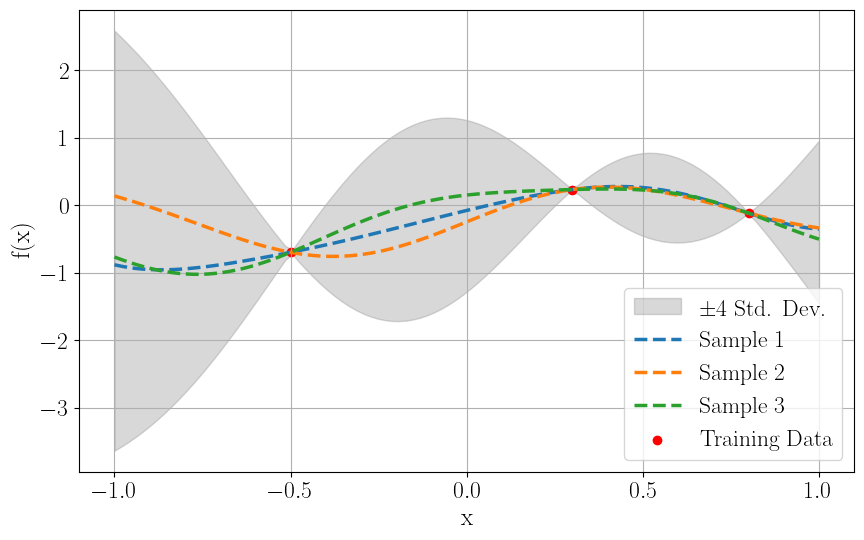

Norm of (C_N × solve(C_N, I) - I) for σ² = 1e-05: 4.1283092161491594e-16


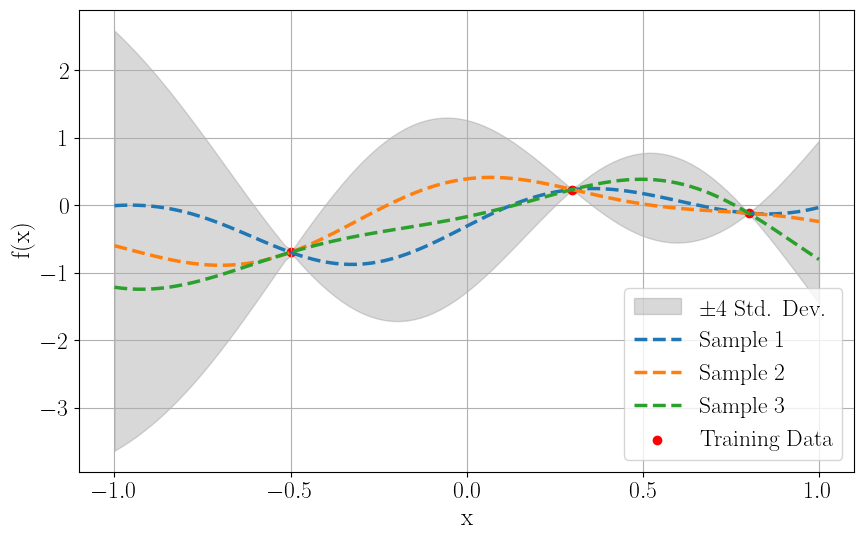

Norm of (C_N × solve(C_N, I) - I) for σ² = 0.01: 4.1283092161491594e-16


In [7]:
# Posterior with different noise levels
X_train = np.array([0.3, -0.5, 0.8])
y_train = np.array([0.23, -0.7, -0.12])

for sigma_2 in [1e-5, 1e-2]:
    exponent = int(np.log10(sigma_2))   
    mean_vector, cov_matrix, std_dev = gp.compute_gp_posterior(
        X_train, y_train, theta_0=1, theta_1=4.0, sigma_2=sigma_2
    )
    samples = np.random.multivariate_normal(mean_vector, cov_matrix, size=3)

    plt.figure(figsize=(10, 6))
    plt.fill_between(
        gp.X_test,
        mean_vector - 4 * std_dev,
        mean_vector + 4 * std_dev,
        color='gray',
        alpha=0.3,
        label="±4 Std. Dev."
    )

    for i, sample in enumerate(samples):
        plt.plot(gp.X_test, sample, label=f"Sample {i+1}", linestyle='--', 
                 linewidth=2.5)

    plt.scatter(X_train, y_train, color='red', label='Training Data')
    #plt.title(rf"GP Posterior with $\sigma^2 = 10^{{{exponent}}}$")
    plt.xlabel("x")
    plt.ylabel(r"f(x)")
    plt.xticks([-1,-0.5,0,0.5,1])
    plt.grid(True)
    plt.legend()
    plt.show()

    # Diagnostics
    C_N, _, _ = gp.compute_cov_matrices(
        X_train, gp.X_test, theta_0=1.0, theta_1=4.0, sigma_2=sigma_2
    )
    print(f"Norm of (C_N × solve(C_N, I) - I) for σ² = {sigma_2}:", 
    gp.diagnostics(C_N))
